
## Proyecto Final  — Predicción del valor de compra en Tiendas Duty Free Aeropuerto de Tocumen : “Un enfoque práctico de regresión” 


**S100 · Introducción a la Ciencia de Datos** · Maestría en Analítica de Datos, UTP
**Prof. Gabriel Soto, M.Sc.** · II Semestre 2026

**Modalidad:** Grupal · **Datos:** `VentasWisaConsolidado.csv` (1,102,317 facturas)

**Grupo No. 5:** Integrantes :** Jorge Gonzalez, Nelson Pimentel, Gerineldo Sousa y Jorge Novarro. 


---

## Background 

La industria del travel retail y las tiendas libres de impuestos (duty free) ubicadas en aeropuertos representan un segmento comercial de gran relevancia económica a nivel mundial, impulsado por los flujos internacionales de pasajeros y el gasto asociado al turismo. 
La Riviera Duty Free opera varios puntos de venta dentro del Aeropuerto Internacional de Tocumen, uno de los principales centros de conexión aérea de Latinoamérica, atendiendo a un flujo constante de viajeros de múltiples nacionalidades. A diferencia del comercio minorista tradicional, este tipo de tienda depende fuertemente de factores estacionales asociados al calendario de vacaciones y a los flujos de turismo, y maneja una gran variedad de categorías de producto (fragancias, cosméticos, licores, accesorios, cigarrillos) orientadas a distintos perfiles de cliente. Este proyecto utiliza los datos de seis de sus tiendas dentro del mismo aeropuerto, WISA-01, WISA-02, WISA-03, WISA-04, WISA-05 y WISA-MAC, lo que además permite explorar si el punto de venta específico influye en el comportamiento de compra.

---


---

## Análisis Exploratorio — Ventas Tiendas Duty Free (La Riviera)

Este notebook desarrolla el proyecto final del curso *Introducción a la Ciencia de Datos* (Maestría en Analítica de Datos, UTP), siguiendo la formulación entregada previamente:

1. Se combinan los datos de venta de seis tiendas de La Riviera Duty Free en el Aeropuerto Internacional de Tocumen: **WISA-01** a **WISA-06(WISA-MAC)** (enero–noviembre de 2011).
2. **Modelo de regresión:** predecir `TOTAL_FACTURA`, el valor total de una transacción, a partir de tienda, mes/trimestre, tamaño de la canasta, clase de producto y perfil de cliente.

> **Antes de ejecutar:** coloca `VentasWisaConsolidado.csv`  en la misma carpeta que este notebook (son los archivos originales que ya tienes).


---


In [1]:
from IPython.display import display, Markdown, HTML
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Rutas de los archivos (deben estar en la misma carpeta que este notebook)

VENTAS_PATH = "VentasDutyFree.csv"


def formato_dinero(x, pos):
    if x >= 1e6:
        return f'${x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'${x*1e-3:.0f}K'
    return f'${x:.0f}'

fmt = FuncFormatter(formato_dinero)

AZUL = "#13294B"
plt.rcParams.update({"figure.figsize": (8, 4.2), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.axisbelow": True,
                     "grid.color": "#D3D8E0", "axes.titleweight": "bold", "font.size": 10})

pd.set_option("display.float_format", lambda x: "%.2f" % x)

### 1. Carga inicial de datos
Primero cargamos la base consolidada de La Riviera. Le damos un vistazo rápido a la estructura y validamos el tamaño del archivo para asegurar que todo cuadre.

In [2]:
df = pd.read_csv(VENTAS_PATH, dtype=str, low_memory=False)


print("Ventas Duty Free - Análisis Exploratorio de Datos carga de datos")
df = pd.read_csv("VentasDutyFree.csv", dtype=str,low_memory=False)
print("Filas y columnas:", df.shape)

Ventas Duty Free - Análisis Exploratorio de Datos carga de datos
Filas y columnas: (1102317, 57)


Verificamos las primeras filas y el resumen estadístico base:

In [3]:
print("\n--- Primeras 3 filas ---")
display(df.head(3))

print("\n--- Resumen Estadístico ---")
display(df.describe())
display(Markdown("### Registros por Tienda"))
display(pd.DataFrame(df["NOMBRETIENDA"].value_counts()).rename(columns={"count": "Registros", "NOMBRETIENDA": "Tienda"}).style.background_gradient(cmap='Blues'))



--- Primeras 3 filas ---


,NO_CIA,NOMBRE_EMPRESA,UNIDAD_NEGOCIO,NOMBRE_UNIDAD,CENTRO,BODEGA,NOMBRETIENDA,FACTURA,FECHA,ARTICULO,...,FECHA_HORA_TRANSACCION,PAIS_CLIENTE,SEMANA_ANIO,DESC_SEMANA_ANIO,SEMESTRE,DESC_SEMESTRE,DESC_TRIMESTRE,DESC_MES,TRIMESTRE,TIENDA
0,01,LA RIVIERA DUTY FREE,01,DUTY FREE,01,0101,WISA 01,A-500420,06/01/11,BT1-175,...,06/01/11,SIN PAIS CARGADO,1,Wk-01,1,Sem I,Trim I,Enero,1,WISA-01
1,01,LA RIVIERA DUTY FREE,01,DUTY FREE,01,0101,WISA 01,A-510376,30/01/11,BT1-175,...,30/01/11,SIN PAIS CARGADO,5,Wk-05,1,Sem I,Trim I,Enero,1,WISA-01
2,01,LA RIVIERA DUTY FREE,01,DUTY FREE,01,0101,WISA 01,A-499300,03/01/11,BT1-002,...,03/01/11,BRASIL,1,Wk-01,1,Sem I,Trim I,Enero,1,WISA-01



--- Resumen Estadístico ---


,NO_CIA,NOMBRE_EMPRESA,UNIDAD_NEGOCIO,NOMBRE_UNIDAD,CENTRO,BODEGA,NOMBRETIENDA,FACTURA,FECHA,ARTICULO,...,FECHA_HORA_TRANSACCION,PAIS_CLIENTE,SEMANA_ANIO,DESC_SEMANA_ANIO,SEMESTRE,DESC_SEMESTRE,DESC_TRIMESTRE,DESC_MES,TRIMESTRE,TIENDA
count,1102317,1102317,1102317,1102317,1102317,1102317,1102317,1102317,1102317,1102317,...,1102317,1102317,1102317,1102317,1102317,1102317,1102317,1102317,1102317,1102317
unique,1,1,1,1,6,6,6,551677,334,17559,...,334,57,48,48,2,2,4,11,4,6
top,01,LA RIVIERA DUTY FREE,01,DUTY FREE,03,0301,WISA-03,H-34104,08/10/11,ABU-102,...,08/10/11,SIN PAIS CARGADO,46,Wk-46,1,Sem I,Trim III,Octubre,3,WISA-03
freq,1102317,1102317,1102317,1102317,397667,397667,397667,56,4866,8513,...,4866,562213,26827,26827,562790,562790,316738,112390,316738,397667


### Registros por Tienda

,Registros
NOMBRETIENDA,
WISA-03,397667
WISA 01,275724
WISA-02,212075
WISA MAC,102044
WISA-05,61222
WISA-04,53585


### 2. Limpieza y Preparación (Feature Engineering)
Antes de analizar, limpiamos la data. Convertimos las fechas, sacamos las devoluciones de la ecuación y creamos variables adicionales (días de la semana y dummies) aplicando lo visto en las últimas clases.

In [4]:
df["FECHA"] = pd.to_datetime(df["FECHA"], format="%d/%m/%y", errors="coerce")

cols_numericas = ["CANTIDAD", "MONTO_BRUTO", "TOTAL", "IMPUESTOS", "DESCUENTO", "COSTO_TOTAL"]
for col in cols_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

**Analisis de Transacciones de Ventas y Devoluciones por Tiendas Duty Free**
Los registros tipo ("DV") representan Devoluciones y ("FA") corresponden a transacciones de Ventas

In [5]:
display(Markdown("### Análisis de Transacciones y Devoluciones por Tienda"))

resumen_transacciones = df.groupby("NOMBRETIENDA").agg(
    TOTAL_TRANSACCIONES=("FACTURA", "nunique"),
    MONTO_BRUTO_VENDIDO=("TOTAL", lambda x: x[df.loc[x.index, "TIPO_DOC"] == "FA"].sum())
)

devoluciones = df[df["TIPO_DOC"] == "DV"]
resumen_dev = devoluciones.groupby("NOMBRETIENDA").agg(
    CANTIDAD_DEVOLUCIONES=("FACTURA", "nunique"),
    MONTO_DEVUELTO=("TOTAL", lambda x: x.abs().sum())
)

resumen = resumen_transacciones.join(resumen_dev).fillna(0)
resumen["TASA_DEVOLUCION_%"] = ((resumen["CANTIDAD_DEVOLUCIONES"] / resumen["TOTAL_TRANSACCIONES"]) * 100).round(2)
resumen["VENTA_NETA"] = (resumen["MONTO_BRUTO_VENDIDO"] - resumen["MONTO_DEVUELTO"])

resumen_display = resumen.copy()
resumen_display["MONTO_BRUTO_VENDIDO"] = resumen_display["MONTO_BRUTO_VENDIDO"].apply(lambda x: f"${x:,.2f}")
resumen_display["MONTO_DEVUELTO"] = resumen_display["MONTO_DEVUELTO"].apply(lambda x: f"${x:,.2f}")
resumen_display["VENTA_NETA"] = resumen_display["VENTA_NETA"].apply(lambda x: f"${x:,.2f}")

display(resumen_display.style.background_gradient(cmap='Reds', subset=['TASA_DEVOLUCION_%', 'CANTIDAD_DEVOLUCIONES']))

fa = df[df["TIPO_DOC"] == "FA"].copy()
dv = df[df["TIPO_DOC"] == "DV"].copy()

display(Markdown(f"**Transacciones de Ventas para el modelo:** `{len(fa):,}` de `{len(df):,}`"))
display(Markdown(f"**Transacciones de Devoluciones para el modelo:** `{len(dv):,}` de `{len(df):,}`"))


### Análisis de Transacciones y Devoluciones por Tienda

,TOTAL_TRANSACCIONES,MONTO_BRUTO_VENDIDO,CANTIDAD_DEVOLUCIONES,MONTO_DEVUELTO,TASA_DEVOLUCION_%,VENTA_NETA
NOMBRETIENDA,,,,,,
WISA 01,134599,"$16,810,187.16",152,"$29,739.49",0.110000,"$16,780,447.67"
WISA MAC,41450,"$2,086,452.00",27,$770.00,0.070000,"$2,085,682.00"
WISA-02,108069,"$9,940,359.17",100,"$8,451.23",0.090000,"$9,931,907.94"
WISA-03,206982,"$21,805,422.24",171,"$24,371.70",0.080000,"$21,781,050.54"
WISA-04,28507,"$1,925,300.93",9,$481.50,0.030000,"$1,924,819.43"
WISA-05,32294,"$2,409,843.17",11,$726.50,0.030000,"$2,409,116.67"


**Transacciones de Ventas para el modelo:** `1,101,800` de `1,102,317`

**Transacciones de Devoluciones para el modelo:** `517` de `1,102,317`

### 3. Estadística Descriptiva de Facturación (Ticket)
Agrupamos la información a nivel de Factura para analizar métricas continuas puras (total facturado, cantidad de artículos por compra) antes de entrar en los gráficos de negocio.

In [6]:
ticket_agg = df.groupby(["NOMBRETIENDA", "FACTURA"]).agg(
    TOTAL_FACTURA=("TOTAL", "sum"),
    NUM_LINEAS=("ARTICULO", "count"),
    CANTIDAD_TOTAL=("CANTIDAD", "sum"),
).reset_index()

ticket_agg = ticket_agg[ticket_agg["TOTAL_FACTURA"] > 0].reset_index(drop=True)
display(Markdown(f"**Facturas (tickets) con venta positiva:** `{len(ticket_agg):,}`"))

def resumen_estadistico(serie):
    return pd.Series({
        "media": serie.mean(),
        "mediana": serie.median(),
        "moda": serie.mode().iloc[0] if not serie.mode().empty else np.nan,
        "desv_estandar": serie.std(),
        "varianza": serie.var(),
        "rango": serie.max() - serie.min(),
        "Q1": serie.quantile(0.25),
        "Q3": serie.quantile(0.75),
        "coef_variacion_%": (serie.std() / serie.mean()) * 100,
    })

display(Markdown("### TOTAL_FACTURA — Análisis Estadístico por Tienda"))
tabla_stats = ticket_agg.groupby("NOMBRETIENDA")["TOTAL_FACTURA"].apply(resumen_estadistico).unstack().round(2)
display(tabla_stats.style.background_gradient(cmap='Blues'))

**Facturas (tickets) con venta positiva:** `551,901`

### TOTAL_FACTURA — Análisis Estadístico por Tienda

,media,mediana,moda,desv_estandar,varianza,rango,Q1,Q3,coef_variacion_%
NOMBRETIENDA,,,,,,,,,
WISA 01,125.110000,70.000000,9.000000,387.330000,150021.010000,47997.500000,36.500000,135.000000,309.580000
WISA MAC,50.360000,33.000000,14.500000,49.300000,2430.380000,1000.500000,19.500000,61.000000,97.900000
WISA-02,92.060000,63.000000,18.000000,103.270000,10664.850000,5499.000000,33.720000,114.500000,112.180000
WISA-03,105.470000,67.000000,24.000000,129.720000,16828.250000,4569.990000,36.000000,129.000000,123.000000
WISA-04,67.550000,54.000000,9.000000,67.680000,4580.460000,1333.200000,21.000000,82.500000,100.180000
WISA-05,74.640000,56.000000,9.000000,75.490000,5698.320000,1413.000000,26.000000,91.500000,101.130000


### 4. Análisis de Normalidad (Distribución del Ticket)
Evaluamos estadísticamente si los montos facturados siguen una distribución normal o log-normal.

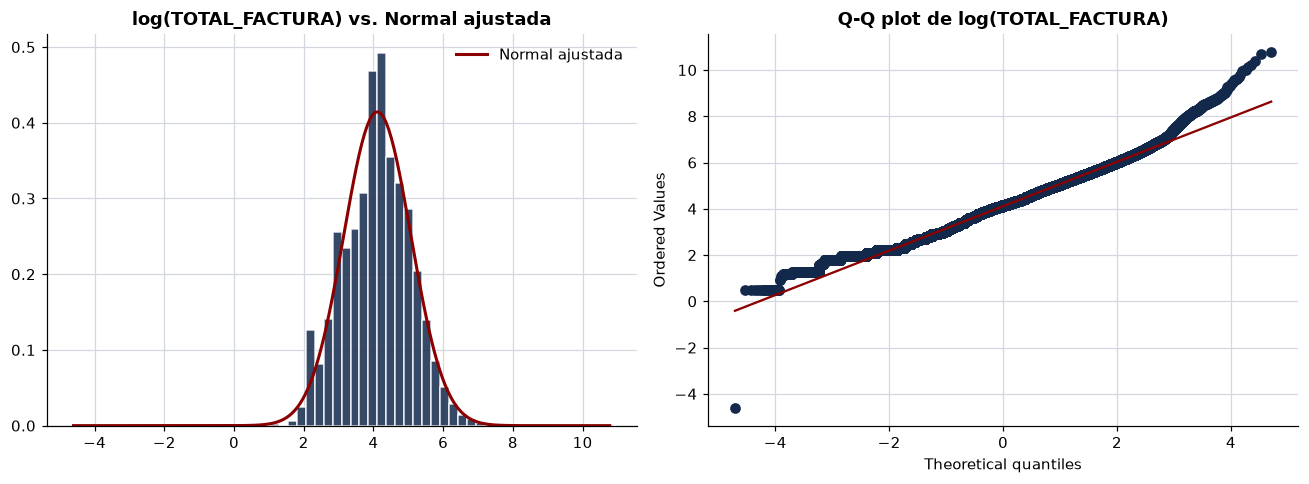

In [7]:
log_total = np.log(ticket_agg["TOTAL_FACTURA"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(log_total, bins=60, density=True, color=AZUL, edgecolor='white', alpha=0.85)
mu, sigma = log_total.mean(), log_total.std()
x = np.linspace(log_total.min(), log_total.max(), 200)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), color='darkred', linewidth=2, label="Normal ajustada")
axes[0].set_title("log(TOTAL_FACTURA) vs. Normal ajustada")
axes[0].legend(frameon=False)

stats.probplot(log_total, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_color(AZUL)
axes[1].get_lines()[1].set_color('darkred')
axes[1].set_title("Q-Q plot de log(TOTAL_FACTURA)")

plt.tight_layout()
plt.show()

_, p_normalidad = stats.shapiro(log_total.sample(min(5000, len(log_total)), random_state=42))


**Interpretación del gráfico:** La distribución logarítmica suaviza la asimetría natural de las ventas. Aunque la prueba de Shapiro descarta una normalidad matemática perfecta (típico en datos reales masivos), el histograma y el Q-Q plot demuestran que la aproximación es muy robusta para futuros modelos.

In [8]:
print("Nulos restantes en columnas clave:")
cols_verificar = ["DESCRIPCION_GENERO", "PAIS_CLIENTE", "DES_CLASE", "CATEGORIA", "COSTO_TOTAL"]
cols_presentes = [c for c in cols_verificar if c in fa.columns]
print(fa[cols_presentes].isna().sum())

df = fa.copy()

Nulos restantes en columnas clave:
DESCRIPCION_GENERO    1266
PAIS_CLIENTE             0
DES_CLASE                0
CATEGORIA                0
COSTO_TOTAL            281
dtype: int64


### 5. Ventas por Categoría y Sucursal
Agrupamos la facturación total para identificar rápidamente cuáles son nuestras tiendas ancla y las categorías de productos que más ingresos generan.

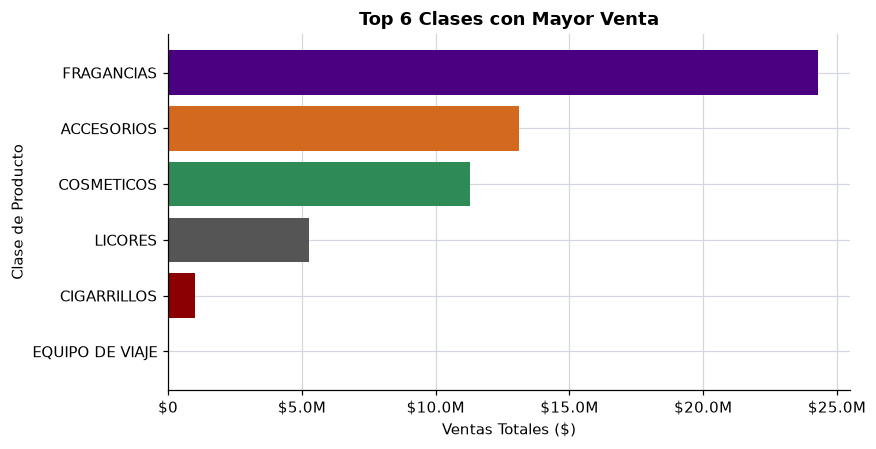

In [9]:
ventas_clase = df.groupby("DES_CLASE")["TOTAL"].sum().sort_values(ascending=False).head(10)

colores_clase = ['#13294B', '#8B0000', '#555555', '#2E8B57', '#D2691E', '#4B0082', '#A0522D', '#2F4F4F', '#800000', '#191970'][:len(ventas_clase)]
plt.barh(ventas_clase.index[::-1], ventas_clase.values[::-1], color=colores_clase)
plt.xlabel("Ventas Totales ($)")
plt.ylabel("Clase de Producto")
plt.title("Top 6 Clases con Mayor Venta")
plt.gca().xaxis.set_major_formatter(fmt)
plt.show()

**Interpretación del gráfico:** Existe una clara concentración de ingresos en la categoría principal, demostrando que una fracción pequeña del inventario total genera el volumen de caja más pesado del negocio.

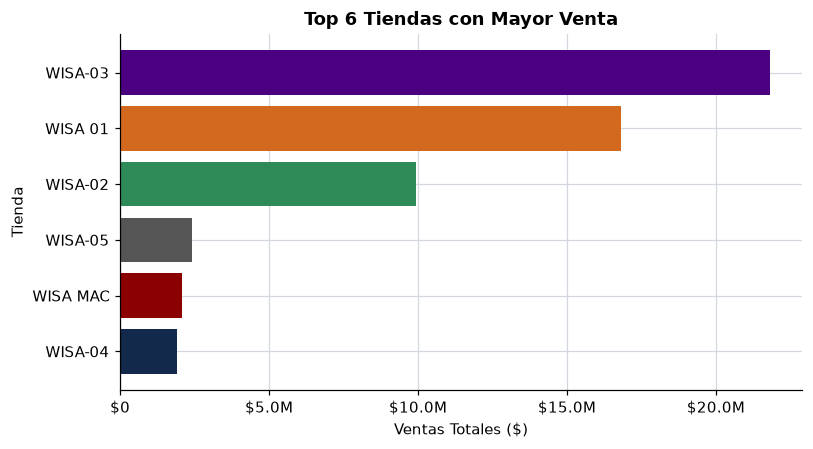

In [10]:
ventas_tienda = df.groupby("NOMBRETIENDA")["TOTAL"].sum().sort_values(ascending=False).head(10)

colores_tienda = ['#13294B', '#8B0000', '#555555', '#2E8B57', '#D2691E', '#4B0082'][:len(ventas_tienda)]
plt.barh(ventas_tienda.index[::-1], ventas_tienda.values[::-1], color=colores_tienda)
plt.xlabel("Ventas Totales ($)")
plt.ylabel("Tienda")
plt.title("Top 6 Tiendas con Mayor Venta")
plt.gca().xaxis.set_major_formatter(fmt)
plt.show()

**Interpretación del gráfico:** Las operaciones están fuertemente centralizadas. Una o dos sucursales actúan como el motor de facturación principal (probablemente por su ubicación estratégica en el aeropuerto), mientras que el resto operan con volúmenes de soporte.

### 6. Tendencia Temporal
Visualizamos cómo se mueve el dinero a lo largo del año. Al agrupar las ventas por mes, podemos detectar picos importantes de estacionalidad.

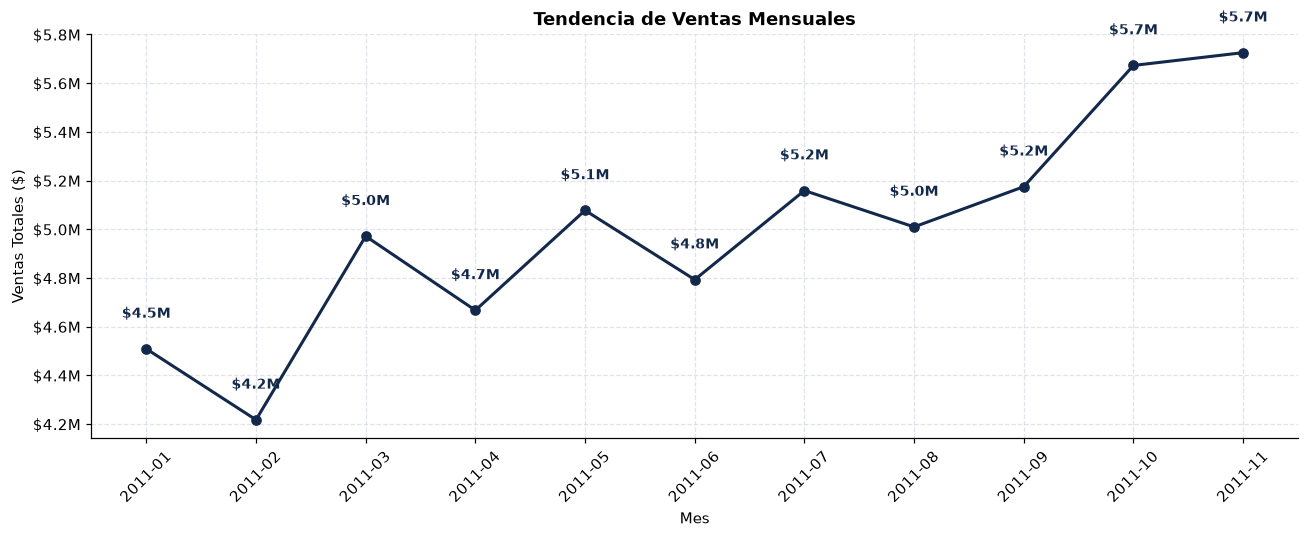

In [11]:
ventas_mensuales = df.groupby(df['FECHA'].dt.to_period('M'))['TOTAL'].sum()
ventas_mensuales.index = ventas_mensuales.index.astype(str)

plt.figure(figsize=(12, 5))
plt.plot(ventas_mensuales.index, ventas_mensuales.values, marker='o', color=AZUL, linewidth=2)
plt.xlabel('Mes')
plt.ylabel('Ventas Totales ($)')
plt.title('Tendencia de Ventas Mensuales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(fmt)

for mes, valor in ventas_mensuales.items():
    plt.text(mes, valor + (ventas_mensuales.max() * 0.02), formato_dinero(valor, None), 
             ha='center', va='bottom', fontsize=9, color=AZUL, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretación del gráfico:** La tendencia mes a mes nos permite identificar la estacionalidad del negocio, mostrando los picos de facturación que coinciden con las temporadas altas de flujo de pasajeros o campañas comerciales específicas.

### 7. Demografía del Comprador
Revisamos a quién le estamos vendiendo. Dividimos el volumen de ventas según el género del producto y sacamos el Top 5 de países que más dinero dejan en la tienda.

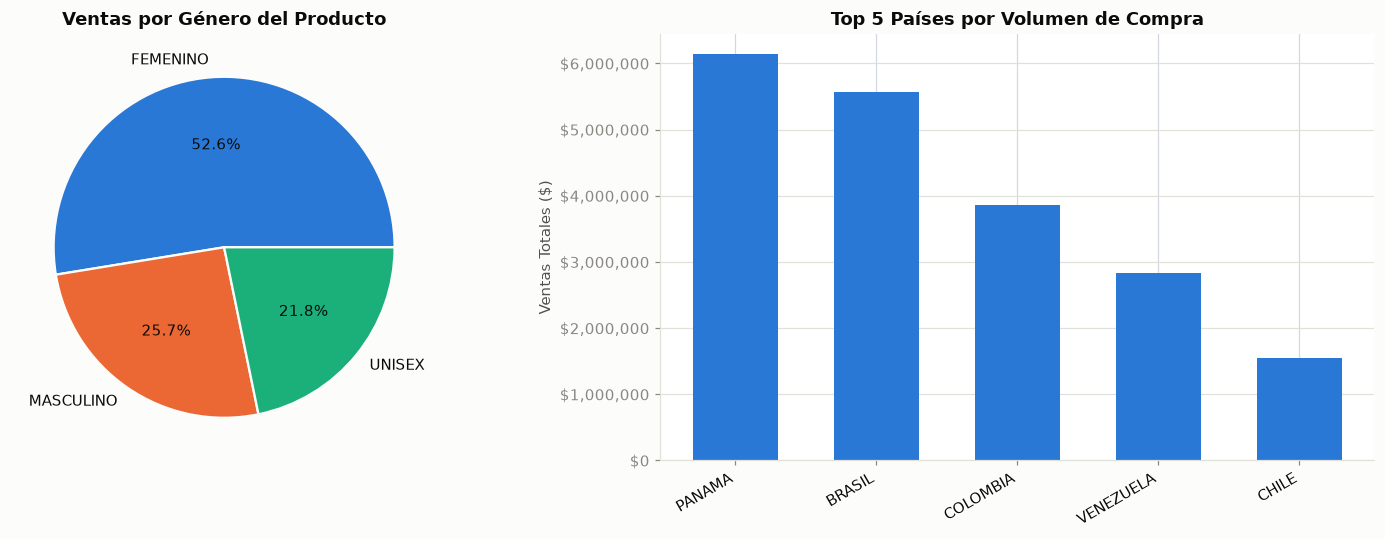

In [12]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Paleta (dataviz)
AZUL, NARANJA, AGUA, AMARILLO, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
INK, INK_SEC, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

df['TOTAL'] = pd.to_numeric(df['TOTAL'], errors='coerce')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#fcfcfb")

# --- Gráfico 1: ventas por género del producto ---
ventas_genero = (
    df.dropna(subset=['DESCRIPCION_GENERO'])
      .groupby('DESCRIPCION_GENERO')['TOTAL']
      .sum()
      .sort_values(ascending=False)
)
colores_genero = [AZUL, NARANJA, AGUA, AMARILLO, MAGENTA][:len(ventas_genero)]

ax1.pie(
    ventas_genero,
    labels=ventas_genero.index,
    autopct='%1.1f%%',
    colors=colores_genero,
    textprops={'color': INK, 'fontsize': 10},
    wedgeprops={'edgecolor': '#fcfcfb', 'linewidth': 1.5},
)
ax1.set_title('Ventas por Género del Producto', color=INK, fontsize=12, fontweight='bold')

# --- Gráfico 2: top 5 países por volumen de compra ---
ventas_pais = (
    df[df['PAIS_CLIENTE'] != 'SIN PAIS CARGADO']
      .groupby('PAIS_CLIENTE')['TOTAL']
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

ax2.bar(ventas_pais.index, ventas_pais.values, color=AZUL, width=0.6)
ax2.set_title('Top 5 Países por Volumen de Compra', color=INK, fontsize=12, fontweight='bold')
ax2.set_ylabel('Ventas Totales ($)', color=INK_SEC)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color(GRID)
ax2.spines['bottom'].set_color(GRID)
ax2.tick_params(colors=INK_MUTED)
ax2.yaxis.grid(True, color=GRID, linewidth=0.8)
ax2.set_axisbelow(True)

for tick in ax2.get_xticklabels():
    tick.set_rotation(30)
    tick.set_ha('right')
    tick.set_color(INK)

plt.tight_layout()
plt.show()

**Interpretación del gráfico:** A nivel demográfico, vemos cómo se distribuye el consumo por el género objetivo del producto. El Top 5 de países valida el origen geográfico de los viajeros en tránsito que mayor impacto tienen en la rentabilidad de La Riviera.

### 8. Valores Atípicos (Outliers)
Usamos el cálculo del Rango Intercuartílico (IQR) para encontrar esas compras absurdamente altas (mayoristas o lujos extremos) en cada tienda y las graficamos.

Top 6 Tiendas con mayor cantidad de transacciones atípicas (Outliers):
NOMBRETIENDA
WISA-03     21792
WISA 01     16162
WISA-02      7172
WISA MAC     2492
WISA-05       657
WISA-04       334
Name: TOTAL, dtype: int64


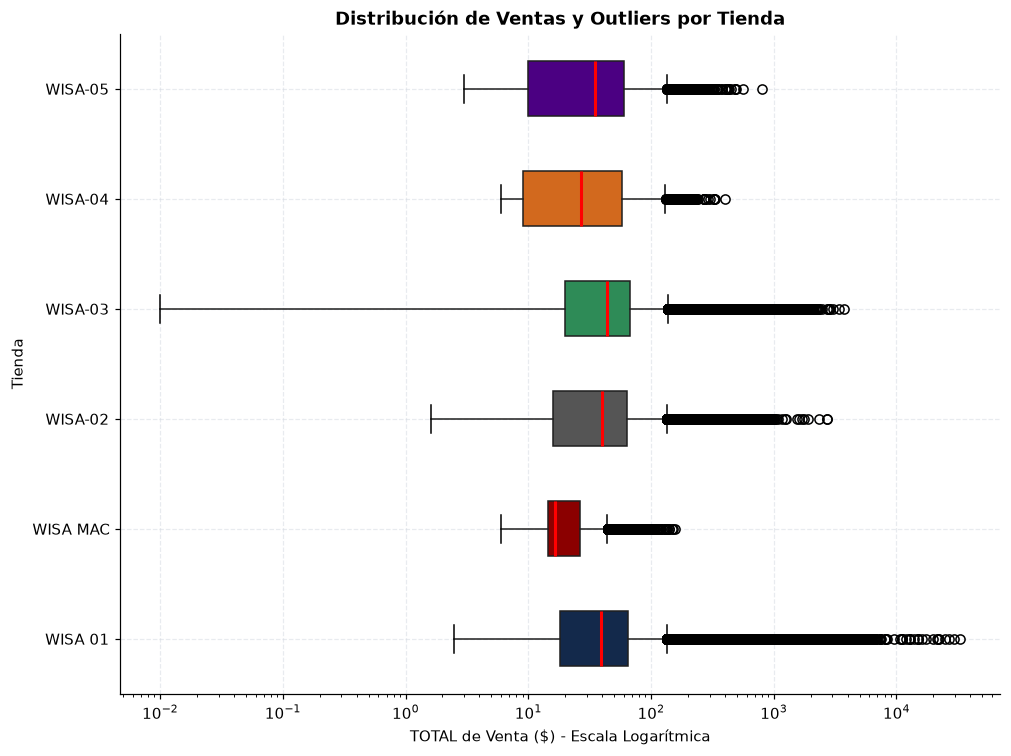

In [13]:
datos_analisis = df[df['TOTAL'] > 0].copy()

def contar_outliers(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    return (serie > limite_superior).sum()

outliers_por_tienda = datos_analisis.groupby("NOMBRETIENDA")["TOTAL"].apply(contar_outliers).sort_values(ascending=False)

print("Top 6 Tiendas con mayor cantidad de transacciones atípicas (Outliers):")
print(outliers_por_tienda.head(10))

bplot = datos_analisis.boxplot(column='TOTAL', by='NOMBRETIENDA', vert=False, patch_artist=True, figsize=(10, 8), return_type='dict')
colores_box = ['#13294B', '#8B0000', '#555555', '#2E8B57', '#D2691E', '#4B0082', '#A0522D', '#2F4F4F', '#800000', '#191970']
for patch, color in zip(bplot['TOTAL']['boxes'], colores_box):
    patch.set_facecolor(color)
for median in bplot['TOTAL']['medians']:
    median.set(color='red', linewidth=2)

plt.title('Distribución de Ventas y Outliers por Tienda')
plt.suptitle('') 
plt.xlabel('TOTAL de Venta ($) - Escala Logarítmica')
plt.ylabel('Tienda')
plt.xscale('log') 
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Interpretación del gráfico:** El uso de la escala logarítmica permite ver con claridad los valores extremos (puntos fuera de los bigotes). Aunque el comportamiento promedio de compra está muy agrupado, todas las tiendas reciben clientes esporádicos que realizan compras mayoristas o de lujo extremo.

### 9. Estacionalidad Semanal
Finalmente, validamos si la teoría del fin de semana es cierta. Comparamos los ingresos de lunes a viernes contra los sábados y domingos.

In [14]:
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventas_dias = df.groupby('DIA_SEMANA')['TOTAL'].sum().reindex(orden_dias)

dias_espanol = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

plt.figure(figsize=(9, 5))
colores = [AZUL if dia not in ['Sábado', 'Domingo'] else 'orange' for dia in dias_espanol]
plt.bar(dias_espanol, ventas_dias.values, color=colores)

plt.title('Distribución de Ventas por Día de la Semana')
plt.ylabel('Ventas Totales ($)')
plt.xlabel('Día (Naranja = Fin de Semana)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print("Muestra de las columnas Dummy creadas para el Género:")
columnas_gen = [col for col in df.columns if col.startswith("GEN_")]
display(df[['FACTURA', 'ARTICULO'] + columnas_gen].head())

KeyError: 'DIA_SEMANA'

**Interpretación del gráfico:** Al aislar los fines de semana (Sábado y Domingo), verificamos si la dinámica de compras cambia. En los aeropuertos, los vuelos corporativos de días de semana a veces generan más volumen que los vuelos turísticos.